## PAN12

**Initial data exploration of the PAN12 dataset.**

This notebook is using a Colab server and is using open source data from the PAN12 dataset extracted from https://zenodo.org/records/3713280

**Getting Started**

As I'm using Google Colab resources and my data is backed up to my Google Drive, the first thing I need to do is mount my Google Drive, import the relevant libraries for converting .xml data into a DF and then identifying the relevant file paths.

**Data Dictionary**

As the process evolves, various dataframes will be created.  Each will be listed below.

- df - the PAN12 dataset converted to a dataframe
- df_sorted - as above but sorted by conversation_id and time
- df_predator_convos - just the conversations involving predators


In [1]:
# mounting my google drive to access the data file

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# relevant imports

import xml.etree.ElementTree as ET 
import pandas as pd


In [3]:
# defining the file path to the xml data file and the text file containing the predator ids

file_path = "/content/drive/MyDrive/research/code/pan_12/pan_12_data/pan_12_train/training_corpus.xml"
predator_ids_path = "/content/drive/MyDrive/research/code/pan_12/pan_12_data/pan_12_train//predators_id.txt"


**Parsing the data**

Up next is a function which takes the .xml file and loads it to a dataframe.

It also loads the chat ids that are labelled as containing predator content and appends to the dataframe.  Finally it sorts the dataframe by conversation_id and then chronologically

In [4]:
# function to parse the xml file and convert it into a pandas dataframe

def parse_pan12_xml(file_path, predator_ids):
    tree = ET.parse(file_path)
    root = tree.getroot()
    records = []
    for conversation in root.findall('conversation'):
        convo_id = conversation.attrib.get('id')
        for message in conversation.findall('message'):
            author = message.findtext('author')
            records.append({
                'conversation_id': convo_id,
                'line':            int(message.attrib.get('line', 0)),
                'user_id':         author,
                'time':            message.findtext('time'),
                'message':         message.findtext('text'),
                'is_predator':     author in predator_ids  # <-- labelled here
            })
    return pd.DataFrame(records)

# Load predator IDs first, then parse
with open(predator_ids_path, 'r') as f:
    predator_ids = set(line.strip() for line in f)

df = parse_pan12_xml(file_path, predator_ids)

# sort the dataframe by conversation_id and time to ensure the messages are in the correct order within each conversation
df_sorted = df.sort_values(by=["conversation_id", "time"], ascending=[True, True]).reset_index(drop=True)


In [5]:
# identify number of rows and columns in the dataframe

print(f"\nShape: {df_sorted.shape}")


Shape: (903607, 6)


**Initial headline view of data**

Below are some basic headline views on the data including -

- Number of unique conversations in the dataset
- Number of unique "persons" in the dataset
- Number of unique "predators" in the dataset
- Number of messages from the predators
- Number of chats with 10 or more messages in

In [6]:
# identify number of unique conversations in the dataframe

print(f"Number of unique conversations: {df_sorted['conversation_id'].nunique()}")

Number of unique conversations: 66927


In [7]:
# identify number of unique users in the dataframe

print(f"Number of unique users: {df_sorted['user_id'].nunique()}")

Number of unique users: 97689


In [8]:
# identify number of unique predators in the dataframe

print(f"Number of unique predators: {df_sorted[df_sorted['is_predator']]['user_id'].nunique()}")

Number of unique predators: 142


In [9]:
# number of messages from predators

print(f"Number of messages from predators: {df_sorted['is_predator'].sum()}")

Number of messages from predators: 40978


In [10]:
# identify number of conversations with 10 or more messages

ten_or_more_messages = df_sorted.groupby('conversation_id').size()
print(f"Conversations with 10 or more messages: {(ten_or_more_messages >= 10).sum()}")

Conversations with 10 or more messages: 15550


The conversations invoving just predators have been added to a separate dataframe called *df_predator_convos*

In [11]:
predator_convo_ids = df_sorted[df_sorted['is_predator']]['conversation_id'].unique()
df_predator_convos = df_sorted[df_sorted['conversation_id'].isin(predator_convo_ids)]

In [12]:
df_predator_convos.shape

(79331, 6)

In [13]:
print(f"Number of unique conversations involving predators: {df_predator_convos['conversation_id'].nunique()}")

Number of unique conversations involving predators: 2016


Below is a basic word cloud from just the predator sides of the conversations in the *df_predator_convos* dataframe

/tmp/ipykernel_1587/2883797247.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('cool')


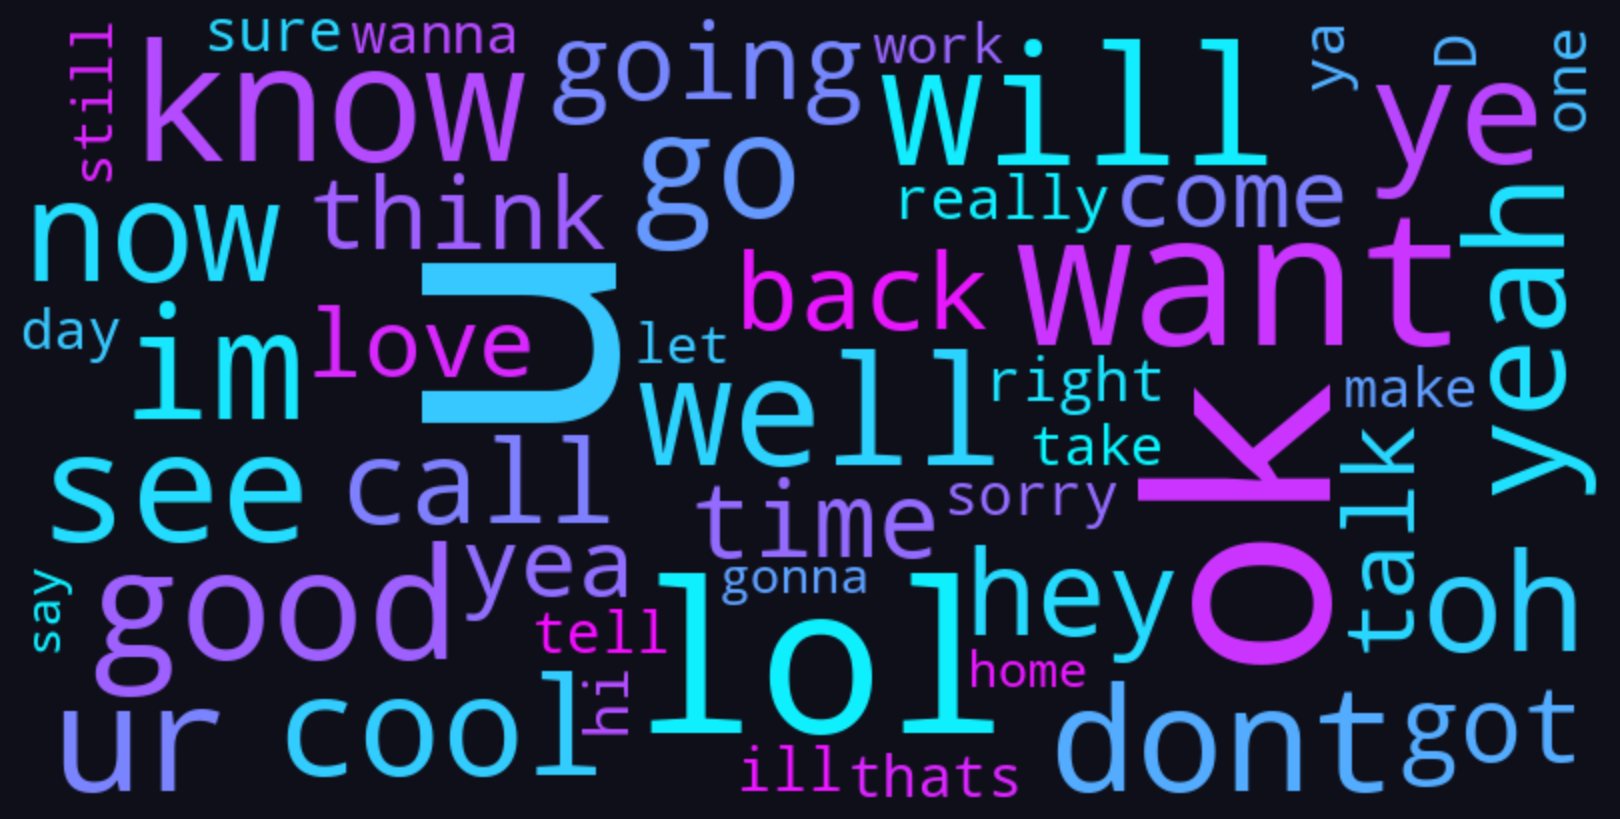

In [14]:
# relevant imports for word cloud visualization

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# create a word cloud for the messages from predators
predator_text = ' '.join(df_sorted[df_sorted['is_predator']]['message'].dropna())

'''
# If considering custome stopwords, the below can be editted...
custom_stopwords = STOPWORDS.copy()
custom_stopwords.update(['lol', 'ok', 'yeah', 'ur', 'u', 'im', 'like', 'll', 've'])
'''

# define a colormap for the word cloud
colormap = plt.cm.get_cmap('cool')

# generate the word cloud with the specified parameters
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='#0f0f1a',
    # stopwords=custom_stopwords,
    colormap='cool',
    max_words=50,
    max_font_size=180,
    min_font_size=12,
    prefer_horizontal=0.85,
    collocations=False,
    relative_scaling=0.5,
    margin=10
).generate(predator_text)

# visualise the word cloud
fig, ax = plt.subplots(figsize=(16, 8), facecolor='#0f0f1a')
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

**Feature Engineering**

At the moment, all conversations are sorted line by line.  The column denoting a predator is also a Boolean value - for later work, this needs to be a binary value.

The initial elements of feature engineering will therefore be merging messages into conversation text blocks and labelling in a binary format.

In [15]:
# join all messages in a conversation into one block of text

conversation_text = (
    df_sorted.groupby('conversation_id')['message']
    .apply(lambda msgs: ' '.join(msgs.dropna()))
    .reset_index()
    .rename(columns={'message': 'text'})
)

In [16]:
# label each conversation: 1 if ANY message in it came from a predator, else 0

conversation_label = (
    df_sorted.groupby('conversation_id')['is_predator']
    .any()
    .astype(int)
    .reset_index()
    .rename(columns={'is_predator': 'is_predator_convo'})
)

In [ ]:
# merge text and label together

df_convos = conversation_text.merge(conversation_label, on='conversation_id')

print(df_convos.shape)
print(df_convos['is_predator_convo'].value_counts())

(66927, 3)
is_predator_convo
0    64911
1     2016
Name: count, dtype: int64
